# Disaster Tweets — Ensemble 1



## 0. Brief Introduction

This notebook serves as the final step for the submission of our **Disaster tweets classification project**. It combines the predictions from three different models: a Logistic Regression, a Transformer-based model, and a RoBERTa-base model. 

These models were not chosen at random; they represent the final range of steps we took in the path to try and achieve a better score in the competition.

Our approach to the challenge came from the project proposed for the CLSBE class Advanced Topics in Predictive Analytics, where we:
1) built an **AI-powered autonomous research agent** that designed, trained, evaluated, and iterated over deep learning models - without human intervention.
2) tuned and tested several **locally hosted Large Language Models** as its “brain” to drive the machine learning experimentation. -- our final model for the iterations was *gemma4*.

The core of the project foccused on these goals. However, as we dug deeper into the competition for *NLP with Disaster Tweets* we became aware of the pre-trained transformer encoder models that could be used to better identify target tweets.

 By researching these models we found out they could not be implemented within our locally run LLM's (in our case, gemma4). We did however test the best model we could, based on our restrictions of a) limited computing power; b) a limit of 1 hour for the program to run. We decided to run **RoBERTA** as it was our best option to achieve a higher F1 score with the limitations we had. This model (as expected) outperformed the ones our locally hosted LLM suggested.

Therefore, as a final solution to the challenge, we decided to 
1) from our locally hosted LLM, with all its prompts, conditions and iterations, select the **two**  model architechtures that returned a higher F1 Classifier score; 
2) create a **Ensemble** of the *RoBERTA* model with our local LLM sugestions (*CountVec + LogReg*, and *Keras Embeding + Transformer*). 

The ensemble approach is used to leverage the strengths of each individual model, aiming to improve overall performance on the validation set and ultimately on the test set for submission.




*note: the model tuning present in the notebook is based on the suggested architechture by our locally hosted LLM (gemma4), with our tested and tunned prompts.*

Sincerely, the team.

Francisca Nunes, Lourenço Sarmento, Tiago Ferreira, José Lopes.

Combines three models to maximize validation F1:
1. **CountVec + LogReg** (agent best — F1 ~0.775)
2. **Keras Embedding + Transformer** (F1 ~0.78)
3. **RoBERTa-base fine-tuned** (F1 ~0.81)

*scores obtained from previous runs / tests

All models share the same train/val split. Ensemble weights and threshold are optimized on the validation set.

In [1]:
import os, sys
os.environ['KERAS_BACKEND'] = 'torch'

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import torch
import keras

try:
    import keras_hub as keras_nlp
except ImportError:
    import keras_nlp

mps_ok = torch.backends.mps.is_available()
DEVICE = 'mps' if mps_ok else 'cpu'
print('Keras:', keras.__version__, '| Device:', DEVICE)

Keras: 3.14.1 | Device: mps


## 1. Load & split data

One shared split used by all three models — essential for a fair ensemble.

In [2]:
df_train = pd.read_csv('../data/train.csv')
df_test  = pd.read_csv('../data/test.csv')

X_train, X_val, y_train, y_val = train_test_split(
    df_train['text'], df_train['target'],
    test_size=0.2, random_state=42, stratify=df_train['target']
)
X_test = df_test['text']

print(len(X_train), 'train /', len(X_val), 'val /', len(X_test), 'test')

6090 train / 1523 val / 3263 test


## 2. Model 1 — CountVec + LogReg (agent best)

Exact hyperparameters from the agent leaderboard winner (`count_logreg_trigrams`, val F1 = 0.7755).

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipe = Pipeline([
    ('vec', CountVectorizer(ngram_range=(1, 3), min_df=2, max_features=30000)),
    ('clf', LogisticRegression(C=1.0, max_iter=2000,
                               class_weight='balanced', solver='liblinear')),
])
logreg_pipe.fit(X_train, y_train)

logreg_val_probs  = logreg_pipe.predict_proba(X_val)[:, 1]
logreg_test_probs = logreg_pipe.predict_proba(X_test)[:, 1]

print(f'LogReg val F1: {f1_score(y_val, (logreg_val_probs >= 0.5).astype(int)):.4f}')

LogReg val F1: 0.7755


### 2.1 Confusion Matrix - CountVec + LogReg (agent best) 

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def display_confusion_matrix(y_true, y_pred, dataset):
    # accepts hard labels (1D) or logits (2D)
    if hasattr(y_pred, 'ndim') and y_pred.ndim == 2:
        y_pred = np.argmax(y_pred, axis=1)
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Not Disaster', 'Disaster'],
        cmap=plt.cm.Blues,
    )
    f1 = f1_score(y_true, y_pred)
    disp.ax_.set_title(f'{dataset} — F1: {f1:.3f}')
    plt.show()
    return f1

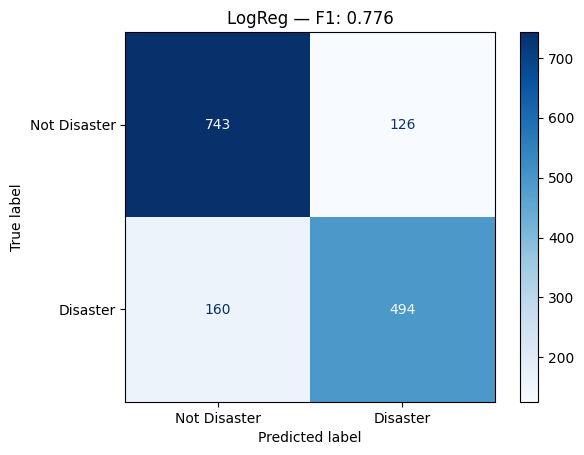

In [34]:
val_logreg = logreg_pipe.predict(X_val)
logreg_val_f1 = display_confusion_matrix(y_val, val_logreg, 'LogReg')

### 2.2 ROC-AUC — CountVec + LogReg (agent best)

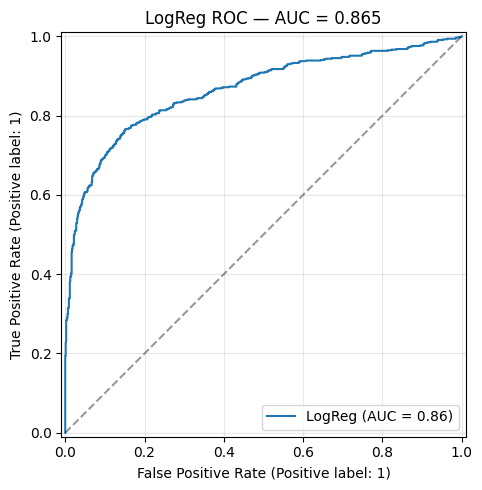

In [ ]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

auc = roc_auc_score(y_val, logreg_val_probs)
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_val, logreg_val_probs, name='LogReg', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title(f'LogReg ROC — AUC = {auc:.3f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Model 2 — Keras Embedding + Transformer

Custom transformer encoder block. Config: embed=128, maxlen=100, bs=32, lr=3e-4.

In [4]:
from keras import layers

VOCAB_SIZE = 20000
MAX_LEN    = 100
EMBED_DIM  = 128
NUM_HEADS  = 4
FF_DIM     = 256
TF_BS      = 32
TF_LR      = 3e-4
TF_EPOCHS  = 10

# Fit the text vectorizer on training data only
text_vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN,
    standardize='lower_and_strip_punctuation',
)
text_vectorizer.adapt(X_train.values)

def transformer_block(x, embed_dim, num_heads, ff_dim, dropout=0.1):
    attn = layers.MultiHeadAttention(num_heads=num_heads,
                                     key_dim=embed_dim // num_heads)(x, x)
    attn = layers.Dropout(dropout)(attn)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(embed_dim)(ff)
    return layers.LayerNormalization(epsilon=1e-6)(x + ff)

def build_transformer():
    inp = keras.Input(shape=(MAX_LEN,), dtype='int32')
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(inp)
    x = layers.Dropout(0.1)(x)
    x = transformer_block(x, EMBED_DIM, NUM_HEADS, FF_DIM)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

tf_model = build_transformer()
tf_model.compile(
    optimizer=keras.optimizers.Adam(TF_LR),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
tf_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 100, 128)  │  2,560,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100, 128)  │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 128)  │     66,048 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 100, 128)  │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 128)  │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 100, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 100, 256)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100, 128)  │     32,896 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 128)  │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,700,801 (10.30 MB)

 Trainable params: 2,700,801 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
X_train_vec = text_vectorizer(X_train.values)
X_val_vec   = text_vectorizer(X_val.values)
X_test_vec  = text_vectorizer(X_test.values)

tf_model.fit(
    X_train_vec, y_train.values,
    validation_data=(X_val_vec, y_val.values),
    batch_size=TF_BS,
    epochs=TF_EPOCHS,
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=2, restore_best_weights=True
    )],
)

transformer_val_probs  = tf_model.predict(X_val_vec).flatten()
transformer_test_probs = tf_model.predict(X_test_vec).flatten()

print(f'Transformer val F1: {f1_score(y_val, (transformer_val_probs >= 0.5).astype(int)):.4f}')

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5502 - loss: 0.6950 - val_accuracy: 0.5706 - val_loss: 0.6791
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6003 - loss: 0.6579 - val_accuracy: 0.6632 - val_loss: 0.5884
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8204 - loss: 0.4093 - val_accuracy: 0.8129 - val_loss: 0.4537
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9169 - loss: 0.2201 - val_accuracy: 0.8135 - val_loss: 0.5312
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9575 - loss: 0.1145 - val_accuracy: 0.7886 - val_loss: 0.5904
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Transformer val F1: 0.7407


### 3.1 Confusion Matrix - Keras Embedding + Transformer

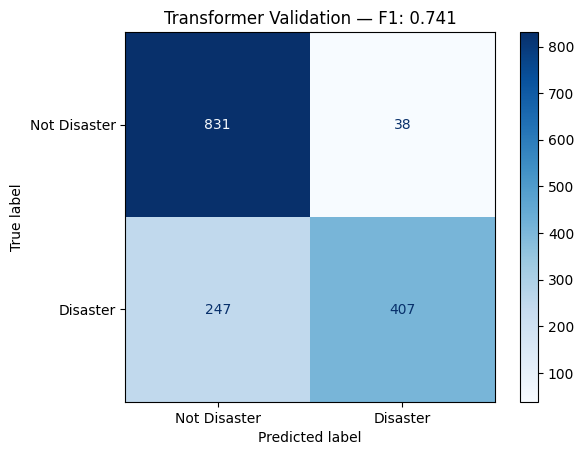

In [28]:
keras_emb_val_f1 = display_confusion_matrix(y_val, transformer_val_probs >= 0.5, 'Transformer Validation')

### 3.2 ROC-AUC - Keras Embedding + Transformer

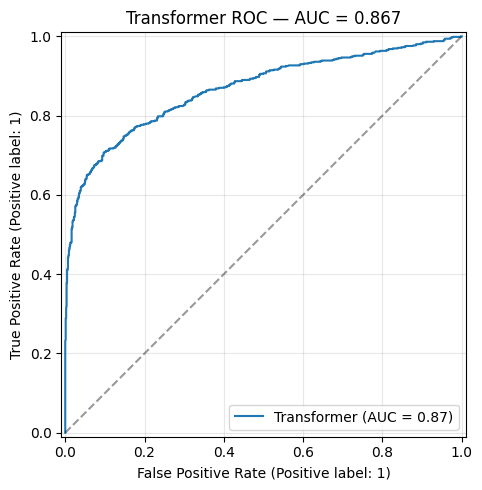

In [29]:
# ROC-AUC — Keras Transformer
auc = roc_auc_score(y_val, transformer_val_probs)
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_val, transformer_val_probs, name='Transformer', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title(f'Transformer ROC — AUC = {auc:.3f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Model 3 — RoBERTa-base fine-tuned

Same setup as the main RoBERTa notebook. Slowest model (~15 min on MPS) but strongest signal.

In [6]:
ROBERTA_BS     = 32
ROBERTA_EPOCHS = 3

preprocessor = keras_nlp.models.RobertaPreprocessor.from_preset(
    'roberta_base_en',
    sequence_length=160,
    name='preprocessor_4_tweets',
)
roberta = keras_nlp.models.RobertaClassifier.from_preset(
    'roberta_base_en',
    preprocessor=preprocessor,
    num_classes=2,
)
roberta.to(DEVICE)

roberta.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.AdamW(1e-5, weight_decay=0.01),
    metrics=['accuracy'],
)

roberta.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=ROBERTA_BS,
    epochs=ROBERTA_EPOCHS,
    class_weight={0: 1.0, 1: 1.4},
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=1, restore_best_weights=True
    )],
)

/Users/josemarialopes/.pyenv/versions/3.13.13/lib/python3.13/site-packages/keras/src/backend/torch/core.py:630: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  return inputs[slices]


Epoch 1/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 455s 2s/step - accuracy: 0.7788 - loss: 0.5600 - val_accuracy: 0.8273 - val_loss: 0.4118
Epoch 2/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.8450 - loss: 0.4357 - val_accuracy: 0.8457 - val_loss: 0.3778
Epoch 3/3
191/191 ━━━━━━━━━━━━━━━━━━━━ 447s 2s/step - accuracy: 0.8757 - loss: 0.3688 - val_accuracy: 0.8332 - val_loss: 0.4074


In [7]:
def softmax2(logits):
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return (e / e.sum(axis=1, keepdims=True))[:, 1]

roberta_val_probs  = softmax2(roberta.predict(X_val.values))
roberta_test_probs = softmax2(roberta.predict(X_test.values))

print(f'RoBERTa val F1: {f1_score(y_val, (roberta_val_probs >= 0.5).astype(int)):.4f}')

48/48 ━━━━━━━━━━━━━━━━━━━━ 36s 740ms/step
102/102 ━━━━━━━━━━━━━━━━━━━━ 80s 782ms/step
RoBERTa val F1: 0.8183


### 4.1 Confusion Matrix - RoBERTa-base fine-tuned

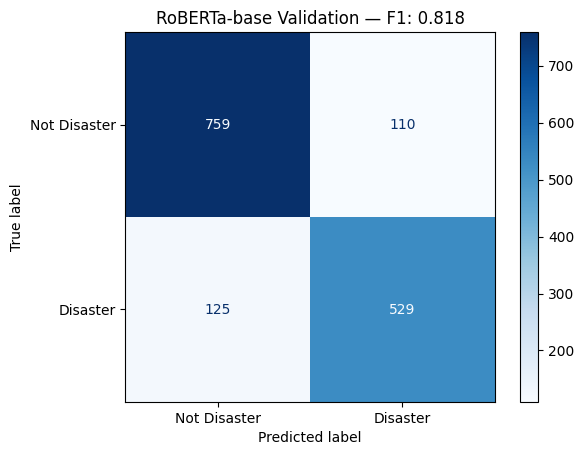

In [32]:
roberta_val_f1 = display_confusion_matrix(y_val, roberta_val_probs >= 0.5, 'RoBERTa-base Validation')

### 4.2 ROC-AUC - RoBERTa-base fine-tuned

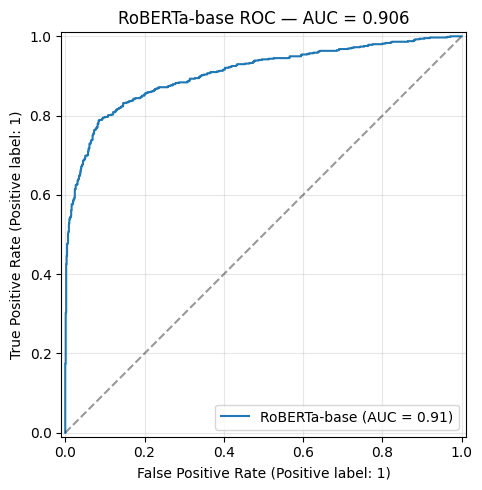

In [35]:
# ROC-AUC — RoBERTa
auc = roc_auc_score(y_val, roberta_val_probs)
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_val, roberta_val_probs, name='RoBERTa-base', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title(f'RoBERTa-base ROC — AUC = {auc:.3f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Ensemble — grid search weights + threshold

Sweep over RoBERTa weight `a`, Transformer weight `b`, LogReg weight `c = 1 - a - b`,
and decision threshold `t`. Pick the combo that maximizes val F1.

In [8]:
print('Individual val F1s:')
print(f'  RoBERTa:     {f1_score(y_val, (roberta_val_probs >= 0.5).astype(int)):.4f}')
print(f'  Transformer: {f1_score(y_val, (transformer_val_probs >= 0.5).astype(int)):.4f}')
print(f'  LogReg:      {f1_score(y_val, (logreg_val_probs >= 0.5).astype(int)):.4f}')

best_f1, best_params = 0, {}

for a in np.linspace(0.5, 0.95, 10):          # RoBERTa weight
    for b in np.linspace(0.0, 1 - a, 8):      # Transformer weight
        c = 1 - a - b                          # LogReg weight
        combo = (a * roberta_val_probs
                 + b * transformer_val_probs
                 + c * logreg_val_probs)
        for t in np.linspace(0.3, 0.7, 21):
            f1 = f1_score(y_val, (combo >= t).astype(int))
            if f1 > best_f1:
                best_f1 = f1
                best_params = dict(
                    roberta=round(float(a), 3),
                    transformer=round(float(b), 3),
                    logreg=round(float(c), 3),
                    threshold=round(float(t), 3),
                )

print(f'\nBest ensemble val F1: {best_f1:.4f}')
print(f'Weights: {best_params}')

Individual val F1s:
  RoBERTa:     0.8183
  Transformer: 0.7407
  LogReg:      0.7755

Best ensemble val F1: 0.8321
Weights: {'roberta': 0.9, 'transformer': 0.057, 'logreg': 0.043, 'threshold': 0.56}


### 5.1 Confusion Matrix - Best Ensemble

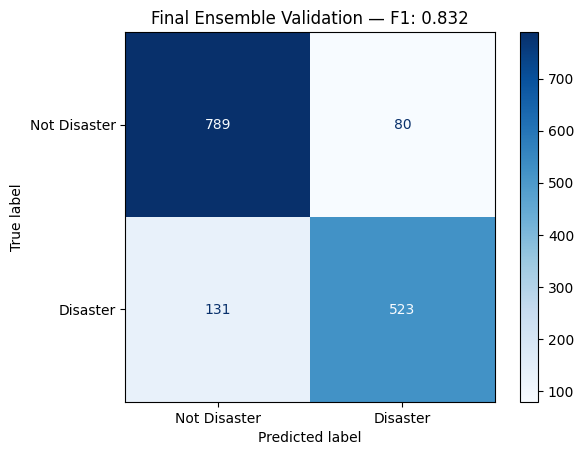

0.8321400159108989

In [37]:
combined_val = (best_params['roberta'] * roberta_val_probs
                + best_params['transformer'] * transformer_val_probs
                + best_params['logreg'] * logreg_val_probs)

ensemble_pred = (combined_val >= best_params['threshold']).astype(int)
display_confusion_matrix(y_val, ensemble_pred, 'Final Ensemble Validation')

## 6. Generate final submission

In [36]:
a = best_params['roberta']
b = best_params['transformer']
c = best_params['logreg']
t = best_params['threshold']

combined_test = (a * roberta_test_probs
                 + b * transformer_test_probs
                 + c * logreg_test_probs)

sub = pd.DataFrame({
    'id':     df_test['id'],
    'target': (combined_test >= t).astype(int),
})
sub.to_csv('../submission-files/submission_final_ensemble.csv', index=False)
print('Saved submission_final_ensemble.csv')
print(sub['target'].value_counts())

Saved submission_final_ensemble.csv
target
0    2012
1    1251
Name: count, dtype: int64
